#### Imports

In [19]:
import os
import sys
import time
import math
import random
import numpy as np
import pandas as pd
from enum import Enum
import concurrent.futures
import matplotlib.pyplot as plt

NOTEBOOK_MODE = hasattr(sys, 'ps1')                                             # Detect whether diplay modules are to be loaded for notebook or terminal running (trick from https://stackoverflow.com/questions/1212779/detecting-when-a-python-script-is-being-run-interactively-in-ipython)
if NOTEBOOK_MODE:
    print("Running in notebook mode...")
    from tqdm.notebook import tqdm, trange
else: 
    print("Running in terminal mode...")
    from tqdm import tqdm, trange

Running in notebook mode...


#### Enum Instantiation & Categorization

In [20]:
class Criterion(Enum):                                                          # Enum for box sorting criterion options
    LENGTH = "x"
    WIDTH = "y"
    HEIGHT = "z"
    AREA = "a"
    VOLUME = "v"

class Metric(Enum):                                                             # Enum for optimization metric options
    PACKING_SCORE = "ps"
    VOLUME_UTILIZATION = "vu"
    COG_Z = "cogz"
    MAX_Z = "maxz"
    ALL = "all"

class Algorithm(Enum):                                                          # Enum for box placement algorithm options
    RANDOM = "random"
    FFD = "ffd"
    BFD = "bfd"
    BNB = "bnb"

MAXIMIZE_METRICS = [Metric.PACKING_SCORE, Metric.VOLUME_UTILIZATION]            # Define which metrics should be maximized vs minimized (higher is better vs lower is better)
MINIMIZE_METRICS = [Metric.COG_Z, Metric.MAX_Z]

#### Global Settings

In [21]:
PALLET_DIMS                     = (1000, 1400, 1400)                            # Length, width, height (X, Y, Z, respectively) in mm
DEFAULT_CRITERION               = Criterion.VOLUME                              # Default criterion for box sorting
DEFAULT_OPTIMIZATION_METRIC     = Metric.MAX_Z                                  # Default score to optimize best fit algorithms for
DEFAULT_ALGORITHM               = Algorithm.BFD                                 # Default box placement algorithm
HOR_ROTATION_ALLOWED_DEFAULT    = True                                          # Default value of whether boxes may be rotated horizontally
VER_ROTATION_ALLOWED_DEFAULT    = True                                          # Default value of whether boxes may be rotated vertically
BNB_OPTIMALITY_GUARANTEE        = False                                         # Disable any code that would sacrifice the guarantee that the BnB algorithm's outcome is the optimal one
DEFAULT_MAX_ATTEMPTS            = 2000                                          # Default cutoff for random attempts to place boxes
SUPPORTED_AREA_PERCENTAGE       = 70                                            # Percentage of pallet area that must be supported under a box for it to be placed
BNB_TOPX_DEFAULT_LIMIT          = 5                                             # Default limit amount for BnB Filter 5

#### Data loading and precomputing

In [22]:
boxtypes = pd.read_csv("./data/boxtypes.csv")                                   # Load box type dimensions
orders = pd.read_csv("./data/orders.csv")                                       # Load orders data
test_orders = pd.read_csv("./data/orders_test.csv")                             # Load test orders data

# Turn dataframes into dicts for instant access without searching 
boxtypes_dict = boxtypes.set_index('ID').to_dict('index')

orders_dict = {}
for _, row in orders.iterrows():
    order_id = row['order_id']
    box_list = []
    for i in range(1, 11):
        col = f'amt_{i}'
        if col in row and pd.notna(row[col]):
            box_list.extend([i] * int(row[col]))
    orders_dict[order_id] = box_list

test_orders_dict = {}
for _, row in test_orders.iterrows():
    order_id = row['order_id']
    box_list = []
    for i in range(1, 11):
        col = f'amt_{i}'
        if col in row and pd.notna(row[col]):
            box_list.extend([i] * int(row[col]))
    test_orders_dict[order_id] = box_list

#### Environment Definition

In [23]:
class Pallet:
    # Basic functionality methods
    def __init__(self, dims=PALLET_DIMS):                                       # Initialize pallet with given dimensions
        # unpack pallet dimensions
        self.size_x, self.size_y, self.size_z = dims
        # Initialize list to store boxes placed on the pallet
        self.boxes = []
        # Initialize heightmap to track box heights at each (x, y) position
        self.heightmap = np.zeros((self.size_x, self.size_y), dtype=np.int32)
        # Initialize sets candidate coordinates (existing box edges) for all potential placements
        self.candidates_x = {0}
        self.candidates_y = {0}
        # Initialize set of candidate coordinate pairs at corner points to optimize placement (in corners between boxes)
        self.extpts = {(0, 0)}
        # Initialize total occupied volume under heightmap counter (boxes + wasted volume)
        self.heightmap_sum = 0
        # Initialize storage of max Z
        self.max_z = 0

    def reset(self):                                                            # Emtpy the pallet
        # Clear the list of boxes
        self.boxes = []
        # Reset the heightmap to all zeros
        self.heightmap = np.zeros((self.size_x, self.size_y), dtype=np.int32)
        # Reset sets of candidate coordinates
        self.candidates_x = {0}
        self.candidates_y = {0}
        # Reset set of extreme points
        self.extpts = {(0, 0)}
        # Reset occupied volume counter
        self.heightmap_sum = 0
        # Reset storage of max Z
        self.max_z = 0

    # Box placement logic
    def get_in_bounds_status(self, x, y, z):                                    # Check if the given (x, y, z) position is within the pallet boundaries
        return (x <= self.size_x) and (y <= self.size_y) and (z <= self.size_z)
    
    def get_in_box_status(self, x, y, z):                                       # Check if the given (x, y, z) position is inside any box on the pallet
        for box in self.boxes:
            if (box['x'] <= x < box['x'] + box['dx'] and
                box['y'] <= y < box['y'] + box['dy'] and
                box['z'] <= z < box['z'] + box['dz']):
                return True
        return False

    def check_box_placement_validity(self, box_dims, x, y):                     # Check if a box of given dimensions may be placed at position (x, y) on the pallet
        # Unpack box dimensions
        dx, dy, dz = box_dims

        # Get the height the bottom of the box will rest on
        z = self.get_max_height_in_area(x, y, dx, dy)
        if z == -1:
            return False

        # Check if the box fits within the pallet boundaries, or return False
        if not self.get_in_bounds_status(x+dx, y+dy, z+dz):
            return False

        # Check if there is enough support under the box, or return False
        box_area = dx * dy
        area_supported = np.sum(self.heightmap[x:x+dx, y:y+dy] == z)
        support_percentage = (area_supported / box_area) * 100
        if support_percentage < SUPPORTED_AREA_PERCENTAGE:
            return False
        
        return True

    def place_box(self, box_dims, x, y):                                        # Attempt to place a box of given dimensions at (x, y) position on the pallet. Return a delta (dict of information to reverse move) if successful, False if not.
        # Unpack box dimensions and get z value to place it at
        dx, dy, dz = box_dims
        z = self.get_max_height_in_area(x, y, dx, dy)

        # Check box placement prerequisites, fail if not met
        if not self.check_box_placement_validity(box_dims, x, y):
            return False
        
        # Save a 'before' snapshot of changed part of the heightmap for delta
        heightmap_backup = self.heightmap[x:x+dx, y:y+dy].copy()

        # Check if we will be adding new candidate coordinates by placing this box
        adding_candidate_x = (x + dx < self.size_x) and ((x + dx) not in self.candidates_x)
        adding_candidate_y = (y + dy < self.size_y) and ((y + dy) not in self.candidates_y)

        # Compute change in local part of heightmap by placing box
        old_local_sum = int(np.sum(heightmap_backup))
        new_local_sum = dx * dy * (z + dz)
        heightmap_sum_delta = new_local_sum - old_local_sum
        
        # Place the box: update the heightmap and max z (if it is increased) and store the dimensions in the boxlist
        self.heightmap[x:x+dx, y:y+dy] = z + dz
        self.heightmap_sum += heightmap_sum_delta
        self.max_z = max(self.max_z, z + dz)
        self.boxes.append({
            'x': x, 'y': y, 'z': z, 'dx': dx, 'dy': dy, 'dz': dz
        })

        # Add box edges to candidate coordinate lists if prerequisites are met
        if adding_candidate_x: self.candidates_x.add(x + dx)
        if adding_candidate_y: self.candidates_y.add(y + dy)

        # Save old set of extreme points calculate the post-move set
        old_extpts = self.extpts.copy()
        self.calculate_extreme_points()

        # Put together all the information needed to reverse this move in a delta dict
        delta = {
            'x': x, 
            'y': y,
            'z': z,
            'dx': dx, 
            'dy': dy,
            'dz': dz,
            'heightmap_backup': heightmap_backup,
            'heightmap_sum_delta': heightmap_sum_delta,
            'x_candidate_added': adding_candidate_x,
            'y_candidate_added': adding_candidate_y,
            'added_extpts': self.extpts.difference(old_extpts),
            'removed_extpts': old_extpts.difference(self.extpts)
        }

        # Return delta to indicate successful placement
        return delta
    
    def remove_box(self, delta):                                                # Remove a box based on the information in the given delta dict
        # Load values from delta dict
        x, y, dx, dy = delta['x'], delta['y'], delta['dx'], delta['dy']
        self.heightmap[x:x+dx, y:y+dy] = delta['heightmap_backup']

        # Revert change to heightmap sum
        self.heightmap_sum -= delta['heightmap_sum_delta']

        # Recompute max_z if removed box was the tallest one
        if delta['z'] + delta['dz'] >= self.max_z:
            self.max_z = np.max(self.heightmap)
        
        # Remove the last box off the list
        self.boxes.pop()
        
        # Remove candidate coordinates if they were added by this move
        if delta['x_candidate_added']: self.candidates_x.remove(x + dx)
        if delta['y_candidate_added']: self.candidates_y.remove(y + dy)

        # Revert extreme points set with information from delta: remove added points, and restore removed points
        self.extpts = self.extpts.difference(delta['added_extpts'])
        self.extpts = self.extpts.union(delta['removed_extpts'])

    # Pallet state and analysis methods    
    def get_max_height_in_area(self, x, y, dx, dy):                             # Get the maximum height in a rectangular area of the heightmap
        # Ensure we don't go out of bounds
        x_end = min(x + dx, self.size_x)                                          
        y_end = min(y + dy, self.size_y)

        # Specify the rectangle being checked
        region = self.heightmap[x:x_end, y:y_end]

        # Return -1 (fail) if the region is of size 0 or smaller
        if region.size <= 0:
            return -1
        
        # Otherwise, return the maximum height in the region
        return np.max(region)
    
    def count_boxes(self):                                                      # Return the number of boxes currently on the pallet
        return len(self.boxes)

    def get_area_usage_at_z(self, z):                                           # Return percentage of area used at specific height (z-value)
        # Get total area and initialize accumulator for used area
        total_area = self.size_x * self.size_y
        used_area_acc = 0
        
        # Check every box for intersection at chosen z, if it is, add its area to used area accumulator
        for box in self.boxes:
            box_bottom = box['z']
            box_top = box_bottom + box['dz']

            if box_bottom <= z <= box_top:
                box_area = box['dx'] * box['dy']
                used_area_acc += box_area

        # Return used/total ratio * 100 (percentage)
        return round(used_area_acc / total_area * 100, 2)

    def calculate_extreme_points(self):                                         # Calculate the set of extreme points (corners of the top layer of boxes) for use as candidate placements
        # Start with the origin as an extreme point
        new_extpts = {(0, 0)} 
    
        for box in self.boxes:
            # Allow stacking boxes on top of each other by including the top corners of boxes as extreme points
            new_extpts.add((box['x'], box['y']))

            # Find existing box edges to use as starting points for projections
            x_end = box['x'] + box['dx']
            y_end = box['y'] + box['dy']
            
            # Trace right edge to Y=0 (find max Y of boxes behind it)
            y_projection_dist = 0
            for other in self.boxes:
                # If the other box is strictly behind right edge, and overlaps in X dimension, and is further to the back, overwrite projection distance
                if other['y'] + other['dy'] <= box['y'] and other['x'] < x_end < other['x'] + other['dx']:
                    y_projection_dist = max(y_projection_dist, other['y'] + other['dy'])
            # Add the point at the end of the right edge and its projection back to Y=0 as extreme point
            new_extpts.add((x_end, y_projection_dist))
            
            # Trace front edge to X=0 (find max X of boxes to the left of it)
            x_projection_dist = 0
            for other in self.boxes:
                # If the other box is strictly to the left of front edge, and overlaps in Y dimension, and is further to the left, overwrite projection distance
                if other['x'] + other['dx'] <= box['x'] and other['y'] < y_end < other['y'] + other['dy']:
                    x_projection_dist = max(x_projection_dist, other['x'] + other['dx'])
            # Add the point at the end of the front edge and its projection back to X=0 as extreme point
            new_extpts.add((x_projection_dist, y_end))
        
        # Remove any points that are out of bounds and set as new extreme points
        for x, y, in new_extpts.copy():
            if x < 0 or y < 0 or x > self.size_x or y > self.size_y:
                new_extpts.remove((x, y))
        self.extpts = new_extpts

    # Pallet metrics and visualization methods
    def get_max_height(self):                                                   # Max height of boxes on the pallet, value to optimize for
        return self.max_z

    def get_min_height(self):                                                   # Min height of boxes on the pallet (usually 0 as it is unlikely boxes will cover every mm^2)
        return np.min(self.heightmap)

    def check_order_fullfillment(self, orderID, order_dict):                    # Check if all boxes in an order are placed on the pallet, if not, returns the percentage
        placed_box_count = self.count_boxes()
        required_box_count = len(get_box_list_from_order(orderID, order_dict))
        if placed_box_count >= required_box_count:
            return 100.0
        else:
            return round(placed_box_count / required_box_count * 100, 2)

    def visualize_heightmap(self, title, ax=None):                              # Visualize the heightmap and return as axis object
        # If no axis object is provided, create a new one
        if ax is None:
            fig, ax = plt.subplots()
        
        image = ax.imshow(self.heightmap.T, origin='lower', cmap='viridis', extent=[0, self.size_x, 0, self.size_y])
        ax.figure.colorbar(image, ax=ax, label='Height (mm)')
        ax.set_title(title)
        ax.set_xlabel('X (mm)')
        ax.set_ylabel('Y (mm)')
        
        return ax

    def visualize_boxes(self, title, ax=None):                                  # Make 3D plot of pallet and return as axis object
        # If no axis object is provided, create a new one with 3D technology
        if ax is None:
            fig = plt.figure()
            ax = fig.add_subplot(111, projection='3d')

        for box in self.boxes:
            # Create a 3D block for each box
            ax.bar3d(box['x'], box['y'], box['z'], box['dx'], box['dy'], box['dz'], alpha=0.7)

        # Set graph size to accurately reflect pallet dimensions
        ax.set_xlim(0, self.size_x)
        ax.set_ylim(0, self.size_y)
        ax.set_zlim(0, self.size_z)

        # Set graph labels and title
        ax.set_xlabel('X (mm)')
        ax.set_ylabel('Y (mm)')
        ax.set_zlabel('Z (mm)')
        ax.set_title(title)

        return ax

    def get_volume_utilization(self):                                           # Return percentage of volume (up to max used z) filled with box
        # Get ceiling and volume of considered space
        max_z = self.get_max_height()
        total_volume = self.size_x * self.size_y * max_z
        
        # Sum up the volume of every box on the pallet
        occupied_volume = 0
        for box in self.boxes:
            box_v = box['dx'] * box['dy'] * box['dz']
            occupied_volume += box_v

        return round(occupied_volume / total_volume * 100, 2)

    def get_center_of_gravity_z(self):                                          # Return the height of the average position of box volume on the pallet (as a proxy for mass, which we have no data about)
        # Initialize accumulators for total box volume and the volume-height product
        total_box_volume_acc = 0
        volume_at_height_acc = 0

        for box in self.boxes:
            # Get each box's volume and add to the total
            box_v = box['dx'] * box['dy'] * box['dz']
            total_box_volume_acc += box_v

            # Get each box's CoG by taking the bottom of the box (z) and adding half the box's height, 
            # then add the box's volume times that height to the total
            box_cog_height = box['z'] + (box['dz'] / 2)
            volume_at_height_acc += box_v * box_cog_height

        # Return -1 (fail) if no boxes are detected
        if total_box_volume_acc == 0:
            return -1
        
        # Take total volume component back out of score to get representation of height of center of gravity
        return round(volume_at_height_acc / total_box_volume_acc, 2)

    def get_packing_score(self):                                                # Calculate score (0-1, higher is better) based on per-layer utilization, each level counting less (100% at the bottom to 0% at the top of used space)
        max_height = self.get_max_height()
        if max_height == 0:
            return 0.0

        total_area = self.size_x * self.size_y
        total_weighted_score = 0.0
        total_possible_weight = 0.0

        # Calculate the mathematical contribution of each box
        for box in self.boxes:
            z_bottom = box['z']
            z_top = box['z'] + box['dz']
            box_area = box['dx'] * box['dy']
            
            # The average weight factor for this specific box's height span
            # (1.0 at bottom of pallet, approaching 0.0 at max_height)
            weight_bottom = 1.0 - (z_bottom / max_height)
            weight_top = 1.0 - (z_top / max_height)
            avg_weight = (weight_bottom + weight_top) / 2.0
            
            # Multiply volume by the average weight
            box_volume = box_area * box['dz']
            total_weighted_score += box_volume * avg_weight
            
        # Calculate what the score would be if the pallet was 100% full up to max_height
        total_possible_volume = total_area * max_height
        total_possible_weight = total_possible_volume * 0.5 # Average weight of a full block is 0.5

        if total_possible_weight == 0:
            return 0.0
            
        return round((total_weighted_score / total_possible_weight), 3)

    def get_total_box_volume(self):                                             # Calculate combined volume of all boxes placed on the pallet
        total_box_volume = 0
        for box in self.boxes:
            volume = box['dx'] * box['dy'] * box['dz']
            total_box_volume += volume
        return total_box_volume

    def get_wasted_space(self):                                                 # Calculate space not occupied by boxes under the heightmap
        total_box_volume = self.get_total_box_volume()
        total_occupied_volume = np.sum(self.heightmap)
        wasted_space = total_occupied_volume - total_box_volume
        return wasted_space

    def get_pallet_results(self, algo, orderID, order_dict, print_mode=False, save_mode=False, bnb_stats=None, nodes=0):  # Get metrics for the pallet, optionally display them, and/or save a composite results image to ./results/
        # Get metrics
        fulfillment = self.check_order_fullfillment(orderID, order_dict)
        volume_util = self.get_volume_utilization()
        area_usage_at_z0 = self.get_area_usage_at_z(0)
        cog_z = self.get_center_of_gravity_z()
        packing_score = self.get_packing_score()
        max_z = self.get_max_height()

        if bnb_stats is not None:
            nodes_evaluated = bnb_stats['nodes']
        else:
            nodes_evaluated = nodes 

        # Determine order set used
        if order_dict == orders_dict:
            set_name = "GivenOrders"
            set_name_display = "Given Orders"
        else:
            set_name = "TestOrders"
            set_name_display = "Test Orders"

        # Build composite figure if build or save mode is active
        if print_mode or save_mode:
            fig = plt.figure(figsize=(19, 7))

            # Heightmap panel
            ax1 = fig.add_subplot(1, 3, 1)
            self.visualize_heightmap(
                f"Heightmap\n{algo.value.upper()} | Order {orderID} | {set_name_display}",
                ax=ax1
            )

            # 3D visualization panel
            ax2 = fig.add_subplot(1, 3, 2, projection='3d')
            self.visualize_boxes(
                f"3D View\n{algo.value.upper()} | Order {orderID}",
                ax=ax2
            )

            # Metrics (text) panel
            ax3 = fig.add_subplot(1, 3, 3)
            ax3.axis('off')
            ax3.set_title("Metrics Summary", fontsize=13, pad=14)

            # Include BnB optimality guarantee tag and candidate limit when relevant
            if algo == Algorithm.BNB and bnb_stats is not None:
                optimal_guarantee = bnb_stats.get('optimality_guarantee', None)
                topx_limit = bnb_stats.get('topx_limit', None)
                if optimal_guarantee is True:
                    optimal_tag = "ON  (exact)"
                elif optimal_guarantee is False:
                    optimal_tag = "OFF (fast)"
                else:
                    optimal_tag = f"{'ON' if BNB_OPTIMALITY_GUARANTEE else 'OFF'} (global)"
            else:
                optimal_tag = "N/A"
                topx_limit = "N/A"

            # Format metrics into neat block of text
            metrics_lines = [
                "  -- Run Information ------------------",
                f"  Algorithm:              {algo.value.upper()}",
                f"  Order ID:               {orderID}",
                f"  Boxes in order:         {len(order_dict[orderID])}",
                f"  Dataset:                {set_name_display}",
                f"  BnB Opt. Guarantee:     {optimal_tag}",
                f"  BnB Candidate Limit:    {topx_limit}",
                f"  Nodes evaluated:        {nodes_evaluated:,}",
                "",
                "  -- Packing Metrics ------------------",
                f"  Max Z Height:           {max_z}        mm",
                f"  CoG Z-height:           {cog_z}     mm",
                f"  Packing Score:          {packing_score}",
                f"  Order Fulfillment:      {fulfillment}      %",
                f"  Volume Utilization:     {volume_util}      %",
                f"  Area Filled at z=0:     {area_usage_at_z0}      %",
            ]

            # Add BnB pruning statistics if BnB is used
            if algo == Algorithm.BNB and bnb_stats is not None:
                total_pruned = (bnb_stats['pruned_rule1'] + bnb_stats['pruned_rule4'] + bnb_stats['pruned_filt1'] + bnb_stats['pruned_filt2'] + bnb_stats['pruned_filt5'])
                metrics_lines += [
                    "",
                    " --- BnB Search Stats -----------------",
                    f"  Branches pruned by rule:\n"
                    f"  Rule 1 (trivial):         {bnb_stats['pruned_rule1']:,}",
                    f"  Rule 4 (tall-low):        {bnb_stats['pruned_rule4']:,}",
                    f"  Branches blocked by filter:\n"
                    f"  Deduplication:            {bnb_stats['pruned_filt1']:,}",
                    f"  Symmetry breaking:        {bnb_stats['pruned_filt2']:,}",
                    f"  Top-x candidate limiting: {bnb_stats['pruned_filt5']:,}",
                    "",
                    f"  Total pruned:             {total_pruned:,}",
                ]

            # Join all lines of metrics text into one variable
            metrics_text = "\n".join(metrics_lines)

            # Add metrics text to panel 3 in a text box
            ax3.text(
                0.05, 0.56, metrics_text,
                transform=ax3.transAxes,
                fontsize=10.5,
                verticalalignment='center',
                fontfamily='monospace',
                bbox=dict(
                    boxstyle='round,pad=0.7',
                    facecolor='#f0f4f8',
                    edgecolor="#4aa56d",
                    linewidth=1.8
                )
            )

            fig.suptitle(
                f"Pallet Results:  {algo.value.upper()}  |  Order {orderID}  |  {set_name_display}",
                fontsize=13, fontweight='bold', y=1.01
            )
            plt.tight_layout()

            # Save the figure to ./results/ with run details in filename
            if save_mode:
                import os
                os.makedirs("./results", exist_ok=True)
                opt_suffix = ""
                if algo == Algorithm.BNB and bnb_stats is not None:
                    g = bnb_stats.get('optimality_guarantee', None)
                    opt_suffix = f"_opt{'ON' if g else 'OFF'}"
                filename = (
                    f"{algo.value.upper()}{opt_suffix}"
                    f"_{set_name}"
                    f"_order{orderID}"
                    f"_ff{int(fulfillment)}"
                    f"_vu{volume_util}"
                    f"_maxz{max_z}"
                    ".png"
                )
                filepath = os.path.join("./results", filename)
                fig.savefig(filepath, dpi=150, bbox_inches='tight')
                print(f"Saved results at: {filepath}")

            # Show the figure in print mode
            if print_mode:
                plt.show()
            else:
                plt.close(fig)

        # Return metrics (with BnB stats if BnB was run and stats are available)
        if algo == Algorithm.BNB and bnb_stats is not None:
            return (fulfillment, volume_util, area_usage_at_z0, cog_z, packing_score, max_z, bnb_stats)
        return (fulfillment, volume_util, area_usage_at_z0, cog_z, packing_score, max_z)

    def simulate_placement(self, x, y, box_dims, requested_metric=Metric.ALL):  # Simulate a box placement on a pallet and return either a specific metric or a dictionary of all metrics from the result
        # Place the box and get a delta to reverse the move after scoring
        delta = self.place_box(box_dims, x, y)
        
        # Return -1 if move is impossible
        if delta == False:
            return -1 
        
        # Calculate requested metric(s)
        if requested_metric == Metric.PACKING_SCORE:
            score = self.get_packing_score()
        elif requested_metric == Metric.VOLUME_UTILIZATION:
            score = self.get_volume_utilization()
        elif requested_metric == Metric.COG_Z:
            score = self.get_center_of_gravity_z()
        elif requested_metric == Metric.MAX_Z:
            score = self.get_max_height()
        else:
            score = {
                "ps": self.get_packing_score(),
                "vu": self.get_volume_utilization(),
                "cogz": self.get_center_of_gravity_z(),
                "maxz": self.get_max_height()
            }
            
        # Undo move to preserve original pallet state
        self.remove_box(delta)
        
        return score


#### Helper Functions

In [24]:
def get_box_properties_from_id(boxid):                                                                                                  # Retrieve length (x), width (y), height (z), area (a) and volume (v) of a box from its ID
    box = boxtypes_dict[boxid]
    
    dx = box['LENGTH']
    dy = box['WIDTH']
    dz = box['HEIGHT']
    
    a = dx * dy
    v = a * dz

    return dx, dy, dz, a, v

def get_box_list_from_order(orderid, order_dict=orders_dict):                                                                           # Retrieve list of box IDs from a given order ID
    return order_dict.get(orderid, [])

def sort_box_list_by_size(box_list, criterion=DEFAULT_CRITERION, invert=False):                                                         # Return a list of box IDs sorted by size (default = largest to smallest). Arguments: sortby to choose sorting criterion (length ("x"), width ("y"), height ("z"), area ("a"), volume ("v")), invert to sort smallest to largest, 
    # The get_box_properties_from_id function returns (x, y, z, a, v), 
    # so map sortby to the correct index of those outputs
    criterion_to_index_dict = {
        "x": 0, "length": 0,
        "y": 1, "width": 1,
        "z": 2, "height": 2,
        "a": 3, "area": 3,
        "v": 4, "volume": 4
    }

    # Extract string value if it's an Enum
    if isinstance(criterion, Enum):
        criterion_value = criterion.value
    else:
        criterion_value = criterion

    # Make sure no bogus value is used
    if criterion_value not in criterion_to_index_dict:
        raise ValueError("Invalid sortby value. Use 'x', 'y', 'z', 'a', or 'v'.")

    # Sort the box list based on the chosen criterion with lambda function
    sorted_list = sorted(
        box_list, 
        key=lambda boxid: get_box_properties_from_id(boxid)[criterion_to_index_dict[criterion_value]], 
        reverse=not invert
    )
    
    return sorted_list
    
def process_order(order, algo, max_attempts=DEFAULT_MAX_ATTEMPTS, criterion=DEFAULT_CRITERION, metric=DEFAULT_OPTIMIZATION_METRIC, order_dict=orders_dict, leave_tqdm=True, optimality_guarantee=None, num_extpts_to_try=None):     # Process a given order using the specified algorithm, max attempts, and sorting criterion. For BnB, returns resultant pallet and node+pruning stats, returns resultant pallet only for other algos
    box_list = get_box_list_from_order(order, order_dict)
    pallet = Pallet()

    if algo == Algorithm.RANDOM:
        nodes = place_box_list_random(pallet, box_list, max_attempts)
        return pallet, nodes

    elif algo == Algorithm.FFD:
        nodes = place_box_list_first_fit_decreasing(pallet, box_list, criterion=criterion)
        return pallet, nodes

    elif algo == Algorithm.BFD:
        nodes = place_box_list_best_fit_decreasing(pallet, box_list, criterion=criterion, opt_metric=metric)
        return pallet, nodes

    elif algo == Algorithm.BNB:
        bnb_stats = place_box_list_branch_and_bound(pallet, box_list, criterion=criterion, leave_tqdm=leave_tqdm, optimality_guarantee=optimality_guarantee, num_extpts_to_try=BNB_TOPX_DEFAULT_LIMIT)
        return pallet, bnb_stats

def get_box_orientations(dx, dy, dz, rot_h=HOR_ROTATION_ALLOWED_DEFAULT, rot_v=VER_ROTATION_ALLOWED_DEFAULT):                           # Get a list of possible orientations for a box with given dimensions, based on allowed rotations
    # initialize list of valid orientations with the original orientation
    orientations = [(dx, dy, dz)]

    # If horizontal rotation is allowed, add the orientation with length and width swapped
    if rot_h:
        orientations.append((dy, dx, dz))

    # If vertical rotation is allowed, add orientations with length and height swapped, and width and height swapped
    if rot_v:
        orientations.append((dx, dz, dy))  # Width and height swapped
        orientations.append((dz, dy, dx))  # Length and height swapped

        # If both horizontal and vertical rotation are allowed, also add the orientations with both rotations applied
        if rot_h:
            orientations.append((dz, dx, dy))  # Length and height swapped, then horizontal rotation
            orientations.append((dy, dz, dx))  # Width and height swapped, then horizontal rotation
    
    return list(set(orientations))  # Remove duplicates if any rotations result in the same orientation

def calculate_box_volumes_list(box_list):                                                                                               # Get a list of volume values corresponding to a given box list
    # Initialize list, append every volume value in the box list to it and return
    box_volumes = []
    for box in box_list:
        _, _, _, _, v = get_box_properties_from_id(box)
        box_volumes.append(v)
    return box_volumes

def calculate_min_height_footprint_list(box_list):                                                                                      # Get a list of footprint areas for each box in the list. The minimum height footprint is the box's largest face area, i.e. the area of the box oriented in such a way that it contibutes to the z-dimension the least
    footprints = []
    for boxid in box_list:
        dx, dy, dz, _, _ = get_box_properties_from_id(boxid)
        min_footprint = max(dx*dy, dx*dz, dy*dz)
        footprints.append(min_footprint)
    return footprints

def calculate_footprint_to_go_dict(box_list):                                                                                           # From a box list, calculate a dict of box index to total minimum height footprint area still to place (sum of largest face of each remaining box)
    footprints = calculate_min_height_footprint_list(box_list)
    total_footprint = sum(footprints)
    footprint_to_go_dict = {}
    cumulative_counter = 0
    for i in range(len(box_list)):
        footprint_to_go_dict[i] = total_footprint - cumulative_counter
        cumulative_counter += footprints[i]
    return footprint_to_go_dict

def calculate_cumulative_volume_dicts(box_list):                                                                                        # From a box list, calculate a dict of box index to cumulative volume placed and a dict of box index to volume still to place
    # Initialize box volume list and dicts, count total box volume and initialize running counter
    box_volumes = calculate_box_volumes_list(box_list)
    cumulative_volume_dict = {}
    volume_to_go_dict = {}
    total_volume = sum(box_volumes)
    cumulative_counter = 0
    
    # Fill dicts with values while keeping count of processed volume
    for i, boxid in enumerate(box_list):
        cumulative_volume_dict[i] = cumulative_counter
        volume_to_go_dict[i] = total_volume - cumulative_counter
        cumulative_counter += box_volumes[i]
        
    return cumulative_volume_dict, volume_to_go_dict

#### Box Placing Algorithms

In [25]:
def place_random_boxes(pallet, num_boxes, box_size_range):                                                                          # Place a number of randomly sized boxes on the pallet
    for _ in range(num_boxes):
        # Generate random box dimensions within the specified range
        dx = np.random.randint(box_size_range[0], box_size_range[1])
        dy = np.random.randint(box_size_range[0], box_size_range[1])
        dz = np.random.randint(box_size_range[0], box_size_range[1])

        # Generate random (x, y) position for the box
        x = np.random.randint(0, pallet.size_x)
        y = np.random.randint(0, pallet.size_y)

        # Attempt to place the box on the pallet
        pallet.place_box((dx, dy, dz), x, y)

def place_box_list_random(pallet, box_list, max_attempts=10000):                                                                    # Place boxes from a given box list randomly on the pallet
    nodes_traversed = 0
    
    for boxid in box_list:
        # Get box dimensions
        dx, dy, dz, _, _ = get_box_properties_from_id(boxid)

        placed = False
        attempts = 0

        while not placed and attempts < max_attempts:
            nodes_traversed += 1
            # Generate random (x, y) position for the box
            x = np.random.randint(0, pallet.size_x)
            y = np.random.randint(0, pallet.size_y)

            # Attempt to place the box on the pallet
            placed = pallet.place_box((dx, dy, dz), x, y)
            attempts += 1

    return nodes_traversed

def place_box_list_first_fit_decreasing(pallet, box_list, criterion=DEFAULT_CRITERION):                                             # Baseline (naive) algorithm: place boxes from a box list on the pallet, biggest boxes (by criterion x, y, z, a, or v) first, with lowest x (then y) values possible
    # Sort the box list by size (largest to smallest)
    sorted_box_list = sort_box_list_by_size(box_list, criterion=criterion, invert=False)
    nodes_traversed = 0

    for boxid in tqdm(sorted_box_list, leave=False):
        # Get base dimensions
        original_dx, original_dy, original_dz, _, _ = get_box_properties_from_id(boxid)
        
        # Get all valid orientations for this box
        orientations = get_box_orientations(original_dx, original_dy, original_dz)

        placed = False

        # Sort candidates to ensure we pack from (0,0) outwards
        cand_x = sorted(list(pallet.candidates_x))
        cand_y = sorted(list(pallet.candidates_y))

        # Try to place box at all (x, y) candidates, and stop once the first one is found
        for x in cand_x:
            if placed: break
            for y in cand_y:
                if placed: break
                for dims in orientations:
                    nodes_traversed += 1
                    if pallet.place_box(dims, x, y):
                        placed = True
                        break
    
    return nodes_traversed

def place_box_list_best_fit_decreasing(pallet, box_list, criterion=DEFAULT_CRITERION, opt_metric=DEFAULT_OPTIMIZATION_METRIC):      # Baseline (naive) algorithm: place boxes from a box list on the pallet, finding the best place for the boxes based on best value of optimization metric after placement
    # Sort the box list by size (largest to smallest)
    sorted_box_list = sort_box_list_by_size(box_list, criterion=criterion, invert=False)
    nodes_traversed = 0

    for boxid in tqdm(sorted_box_list, desc="Placing boxes (Best Fit)", leave=False):
        # Get base dimensions
        original_dx, original_dy, original_dz, _, _ = get_box_properties_from_id(boxid)
        
        # Get all valid orientations for this box
        orientations = get_box_orientations(original_dx, original_dy, original_dz)

        # Initialize best score trackers for this specific box
        if opt_metric in MAXIMIZE_METRICS:
            best_score = -1                     # Worse than any possible score as minimum for both maximization metrics is 0, making -1 a safe worst score.
        else:
            best_score = PALLET_DIMS[2] + 100   # Worse than any possible score as maximum for both minimization metrics is max z height.
        
        # Initialize storage for best placement found for this box and whether one has been found
        best_placement = None
        found_valid_move = False

        # Sort candidates to ensure we check from (0,0) outwards
        cand_x = sorted(list(pallet.candidates_x))
        cand_y = sorted(list(pallet.candidates_y))

        # Check all possible placements
        for dims in orientations:
            for x in cand_x:
                for y in cand_y:
                    nodes_traversed += 1

                    # Precheck conditions for place_box() before running it to save compute
                    # If prechecks pass, simulate the placement compare the resulting metric score without affecting the real pallet state
                    if pallet.check_box_placement_validity(dims, x, y):
                        # Calculate the score based on the chosen metric
                        score = pallet.simulate_placement(x, y, dims, opt_metric)

                        # Compare score against best found so far
                        if opt_metric in MAXIMIZE_METRICS:
                            if score > best_score:
                                best_score = score
                                best_placement = (dims, x, y)
                                found_valid_move = True
                        else: # Minimize metrics
                            if score < best_score:
                                best_score = score
                                best_placement = (dims, x, y)
                                found_valid_move = True

        # After finding best placement for box, place it on the real pallet if a valid move was found
        if found_valid_move and best_placement:
            b_dims, b_x, b_y = best_placement
            pallet.place_box(b_dims, b_x, b_y)
        else:
            print(f"Could not place box {boxid} anywhere.")
            pass

    return nodes_traversed

def place_box_list_branch_and_bound(pallet, box_list, criterion=DEFAULT_CRITERION, leave_tqdm=True, optimality_guarantee=None, num_extpts_to_try=None):   # Recursive backtracking algorithm to find the optimal placement of boxes from a box list on the pallet, with pruning based on bounding functions and branching filters
    # PREWORK AND INITIALIZATIONS
    sorted_box_list = sort_box_list_by_size(box_list, criterion=criterion, invert=False)                    # Sort the box list by size (largest to smallest)
    use_guarantee = BNB_OPTIMALITY_GUARANTEE if optimality_guarantee is None else optimality_guarantee      # Override global optimality guarantee if specified
    current_sequence = []                                                                                   # Initialize a list of deltas for the current sequence of placements to traverse both ways
    best_sequence = None                                                                                    # Initialize storage for the best sequence of placements found

    temp_pallet = Pallet()                                                                                  # Initialize best score tracker for the entire placement
    place_box_list_best_fit_decreasing(temp_pallet, sorted_box_list, criterion=criterion)                   # Run the BFD algorithm first to get a decent initial score to beat, making pruning more aggressive
    best_score = temp_pallet.get_max_height() + 1                                                           # Make sure BnB algorithm doesn't fail catastrophically if unable to find a better solution than BFD

    box_count = len(box_list)
    node_count_estimate = 139828400000 + (4413.08 - 139828400000) / (1 + (box_count/210.6191) ** 7.855901)  # Equation derived from curve fitting average BnB node counts per box amount

    # PRECALCULATIONS
    box_orientations_dict = {}                                                                              # Precalculate box orientations for this order
    for boxid in set(sorted_box_list):
        dx, dy, dz, _, _ = get_box_properties_from_id(boxid)
        box_orientations_dict[boxid] = get_box_orientations(dx, dy, dz)
    
    tallest_remaining_orientations = []                                                                     # Rule 4 (Tall-Low): Precalculate tallest remaining box orientations by depth
    for i in range(len(sorted_box_list)):
        tallest_remaining_id = max(
            sorted_box_list[i:],
            key=lambda bid: min(get_box_properties_from_id(bid)[:3])
        )
        tallest_remaining_orientations.append(box_orientations_dict[tallest_remaining_id])

    dimension_tuples = []                                                                                   # Filter 2 (Symmetry Breaking): Make list of box dimensions tuples
    for boxid in sorted_box_list:
        dimension_tuples.append(tuple(sorted(get_box_properties_from_id(boxid)[:3])))

    def recursive_place(box_index):                                                                         # Define recursive function to place boxes one by one and prune as needed
        # Take variables into local scope of the recursive function
        nonlocal best_score, best_sequence, count_nodes, count_bound1, count_bound4, count_filt1, count_filt2, count_filt5

        # BASE CASE: if all boxes are placed, evaluate score and update best if needed
        if box_index == len(sorted_box_list):
            current_score = pallet.get_max_height()
            if current_score < best_score:
                best_score = current_score
                best_sequence = list(current_sequence)
            return
        
        # BOUNDING CASES
        # Rule 1 (Trivial Rule)
        if pallet.get_max_height() >= best_score:                                                           # Calculate if the current partial state is already worse than the best known full state and prune if so
            counter_bound1.update(1)
            count_bound1 += 1
            return
        
        # Rule 4 (Tall-Low)
        t_orientations = tallest_remaining_orientations[box_index]                                          # Check if tallest remaining box placed at its lowest possible candidate position exceeds best_score and prune if so
        min_landing_z = PALLET_DIMS[2] + 100
        
        for x, y in pallet.extpts:
            for dims in t_orientations:
                if pallet.check_box_placement_validity(dims, x, y):
                    landing_z = pallet.get_max_height_in_area(x, y, dims[0], dims[1])
                    min_landing_z = min(min_landing_z, landing_z + dims[2])

        if PALLET_DIMS[2] + 100 > min_landing_z >= best_score:
            counter_bound4.update(1)
            count_bound4 += 1
            return

        # BRANCHING CASE
        boxid = sorted_box_list[box_index]
        orientations = box_orientations_dict[boxid]
        sorted_extpts = sorted(pallet.extpts)

        seen_profile_keys = set() if not use_guarantee else None                                            # Filter 1 (Deduplication): Initialize set of unique seen profiles

        if dimension_tuples[box_index] == dimension_tuples[box_index - 1]:                                  # Filter 2 (Symmetry Breaking): Check if current box matches dimensions of previous box and record (dims, x, y) as comparison key
            filt2_key = current_sequence[-1]
        else:
            filt2_key = None

        candidate_placements = []                                                                           # Make list of valid placement candidates to loop through
        for dims in orientations:
            for x, y in sorted_extpts:
                if pallet.check_box_placement_validity(dims, x, y):
                    landing_z = pallet.get_max_height_in_area(x, y, dims[0], dims[1])
                    top_z     = landing_z + dims[2]
                    score     = (top_z, x + y)
                    candidate_placements.append((score, dims, x, y))

        if not use_guarantee and num_extpts_to_try is not None:                                             # Filter 5 (Top-X candidates): if optimality need not be guaranteed and candidate limit is specified, score all orientation + placement candidates by resultant box height, then lowest x+y placement, and only branch on the top X scoring candidates
            candidate_placements.sort(key=lambda c: c[0])
            candidate_placements_filtered = max(0, len(candidate_placements) - num_extpts_to_try)
            candidate_placements = candidate_placements[:num_extpts_to_try]
            if candidate_placements_filtered > 0:
                counter_filt5.update(candidate_placements_filtered)
                count_filt5 += candidate_placements_filtered

        # Iterate through valid candidate placements, attempt to place box, and recurse after each valid placement
        for _, dims, x, y in candidate_placements:
            if not use_guarantee:                                                                           # Filter 1 (Deduplication): if optimality need not be guaranteed, check if placing the box in the same orientation at another extreme point leads to the same resultant z-height. This is likely to lead to a very similar heightmap structure, so prune all these candidate branches except for one representative. 
                z = pallet.get_max_height_in_area(x, y, dims[0], dims[1])
                profile_key = (dims, z)
                if profile_key in seen_profile_keys:
                    counter_filt1.update(1)
                    count_filt1 += 1
                    continue

            if filt2_key is not None and filt2_key > (dims, x, y):                                          # Filter 2 (Symmetry Breaking): if a comparison key is registered and the candidate placement is smaller than the key (checked value by value in the tuples ((dx, dy, dz), x, y) ), prune branch as it would lead to an identical resultant pallet in terms of dimensions but with different boxes (of the same or different box IDs, like a type 8 or 10 box, which are dimensionally identical) occupying the same place.
                counter_filt2.update(1)
                count_filt2 += 1
                continue

            delta = pallet.place_box(dims, x, y)                                                            # Place box if branch not filtered
            if not delta:
                continue

            if not use_guarantee:                                                                           # Only add comparison key if box was successfully placed
                seen_profile_keys.add(profile_key)

            current_sequence.append((dims, x, y))                                                           # Add placement to sequence and recurse
            pbar.update(1)
            count_nodes += 1
            recursive_place(box_index + 1)
            current_sequence.pop()
            pallet.remove_box(delta)

    # Initialize non-tqdm counters for nodes and pruning for metrics extraction
    count_nodes         = 0
    count_bound1        = 0
    count_bound4        = 0
    count_filt1         = 0
    count_filt2         = 0
    count_filt5         = 0

    # Start the recursive search starting with the first box (index 0) and keep track of branches and bounds
    pbar                = tqdm(desc="Evaluating Placements", unit=" nodes", leave=leave_tqdm, total=round(node_count_estimate))
    counter_bound1      = tqdm(desc="Number of branches pruned by bounding rule 1",     unit=" prunes", leave=leave_tqdm)
    counter_bound4      = tqdm(desc="Number of branches pruned by bounding rule 4",     unit=" prunes", leave=leave_tqdm)
    counter_filt1       = tqdm(desc="Number of branches filtered by deduplication",     unit=" prunes", leave=leave_tqdm)
    counter_filt2       = tqdm(desc="Number of branches filtered by symmetry breaking", unit=" prunes", leave=leave_tqdm)
    counter_filt5       = tqdm(desc="Number of branches filtered by top-x limiting",    unit=" prunes", leave=leave_tqdm)
    recursive_place(0)

    # Reconstruct the optimal pallet state using the best sequence found
    if best_sequence:
        for dims, x, y in best_sequence:
            pallet.place_box(dims, x, y)
    else:
        print("Branch and Bound failed. No valid placements found.")

    # Put node and pruning stats into a dict and return for metrics extraction
    bnb_stats = {
        'nodes':                count_nodes,
        'pruned_rule1':         count_bound1,
        'pruned_rule4':         count_bound4,
        'pruned_filt1':         count_filt1,
        'pruned_filt2':         count_filt2,
        'pruned_filt5':         count_filt5,
        'best_score':           best_score,
        'optimality_guarantee': use_guarantee,
        'topx_limit':           num_extpts_to_try
    }
    return bnb_stats


#### Testing Functions

In [26]:
def run_random_fulfillment_test(start_order=1000, end_order=3999, order_dict=test_orders_dict, trials=500, max_max_attempts=10000, step=10, save_result=True):
    # Final lists for plotting, max_attempts values on x axis, average fulfillment on y-axis
    x_axis = [] 
    y_axis = []

    # If no final order is specified, let the final order be the last entry in the dict
    if end_order is None:
        end_order = max(order_dict.keys())

    # Get the order IDs to test between the start and end order IDs
    order_ids = [order_id for order_id in sorted(order_dict.keys()) if start_order <= order_id <= end_order]
    
    # Prevent running on emtpy list
    if not order_ids:
        print("No orders found in the specified range.")
        return

    # Create an evenly spaced array of indices from 0 to the last index of order_ids
    indices = np.round(np.linspace(0, len(order_ids) - 1, trials)).astype(int)
    
    # Map those indices back to the actual order IDs
    selected_order_ids = [order_ids[i] for i in indices]

    # Use max and step size to get final range of max_attempts values (x-axis)
    max_attempts_range = range(step, max_max_attempts + 1, step)

    for max_attempts in tqdm(max_attempts_range, desc="Testing max_attempts values", position=0, leave=True):
        # Keep track of scores for this max_attempts value
        scores = []

        # Iterate directly through our pre-calculated deterministic list
        for order_id in tqdm(selected_order_ids, leave=False):
            box_list = get_box_list_from_order(order_id, order_dict)

            # Initialize pallet and pack it with the random algorithm
            pallet = Pallet()
            place_box_list_random(pallet, box_list, max_attempts)

            # Get fulfillment score based on chosen order dict
            score = pallet.check_order_fullfillment(order_id, order_dict)
            
            # Add score to scores list
            scores.append(score)

        # Average the scores for this max_attempts value
        avg_score = np.mean(scores)

        # Add the datapoints to the final lists
        x_axis.append(max_attempts)
        y_axis.append(avg_score)

    # Plot the results
    plt.figure()
    plt.plot(x_axis, y_axis)

    plt.title(f"Random placement algorithm fulfillment scores ({trials} trials/step)")
    plt.xlabel("Maximum attempts per box")
    plt.ylabel('Average order fulfillment percentage')
    plt.ylim(0, 105)

    if save_result:
        save_path = './results/figures/random_fulfillment_test.png'
        plt.savefig(save_path, dpi=300)

    plt.show()

def run_optimality_guarantee_test(start_order=1, end_order=None, order_dict=test_orders_dict, criterion=DEFAULT_CRITERION, metric=Metric.MAX_Z, print_pallets=False, save_pallets=False):    # Run BnB with and without the optimality guarantee on a range of orders and export a comparison CSV
    # If no final order is specified, let the final order be the last entry in the dict
    if end_order is None:
        end_order = max(order_dict.keys())

    # Base final filename on whether given or test orders are tested
    if order_dict == orders_dict:
        prefix = "O"
    else:
        prefix = "T"

    # Get the order IDs to test between the start and end order IDs
    order_ids = [order_id for order_id in sorted(order_dict.keys()) if start_order <= order_id <= end_order]

    result_rows = []

    for order_id in tqdm(order_ids, desc="Testing orders", unit=" orders"):
        print(f"\n----------------------------------------------------------------------------------------------------------------------------")
        print(f"----------------------------------------------------------------------------------------------------------------------------")
        print(f"Running order {order_id} with guarantee off...")

        # Run order with no optimality guarantee and get stats
        pallet_no_guarantee = Pallet()
        box_list = get_box_list_from_order(order_id, order_dict)
        stats_no_guarantee = place_box_list_branch_and_bound(
            pallet_no_guarantee, box_list, criterion=criterion, leave_tqdm=False, optimality_guarantee=False
        )
        score_no_guarantee = pallet_no_guarantee.get_max_height() if metric == Metric.MAX_Z else None
        pallet_no_guarantee.get_pallet_results(algo=Algorithm.BNB, orderID=order_id, order_dict=order_dict, print_mode=print_pallets, save_mode=save_pallets, bnb_stats=stats_no_guarantee)

        print(f"\n----------------------------------------------------------------------------------------------------------------------------")
        print(f"Running order {order_id} with guarantee on...")

        # Run order with optimality guarantee and get stats
        pallet_with_guarantee = Pallet()
        stats_with_guarantee= place_box_list_branch_and_bound(
            pallet_with_guarantee, box_list, criterion=criterion, leave_tqdm=False, optimality_guarantee=True
        )
        score_with_guarantee = pallet_with_guarantee.get_max_height() if metric == Metric.MAX_Z else None
        pallet_with_guarantee.get_pallet_results(algo=Algorithm.BNB, orderID=order_id, order_dict=order_dict, print_mode=print_pallets, save_mode=save_pallets, bnb_stats=stats_with_guarantee)

        # Calculate differences, absolute and relative
        def calculate_row_difference(val_no_guarantee, val_with_guarantee):
            abs_diff = abs(val_no_guarantee - val_with_guarantee)
            factor   = round(val_no_guarantee / val_with_guarantee, 4) if val_with_guarantee != 0 else "N/A" # Avoid division by 0
            return abs_diff, factor

        nodes_diff, nodes_factor    = calculate_row_difference(stats_no_guarantee['nodes'],                 stats_with_guarantee['nodes'])
        r1_diff,    r1_factor       = calculate_row_difference(stats_no_guarantee['pruned_rule1'],          stats_with_guarantee['pruned_rule1'])
        r4_diff,    r4_factor       = calculate_row_difference(stats_no_guarantee['pruned_rule4'],          stats_with_guarantee['pruned_rule4'])
        f1_diff,    f1_factor       = calculate_row_difference(stats_no_guarantee['pruned_filt1'],          stats_with_guarantee['pruned_filt1'])
        f2_diff,    f2_factor       = calculate_row_difference(stats_no_guarantee['pruned_filt2'],          stats_with_guarantee['pruned_filt2'])
        f5_diff,    f5_factor       = calculate_row_difference(stats_no_guarantee['pruned_filt5'],          stats_with_guarantee['pruned_filt5'])

        result_rows.append({
            'order_id':                 order_id,
            # Packing result
            'score_no_guarantee':       score_no_guarantee,
            'score_with_guarantee':     score_with_guarantee,
            # Nodes
            'nodes_no_guarantee':       stats_no_guarantee['nodes'],
            'nodes_with_guarantee':     stats_with_guarantee['nodes'],
            'nodes_diff_abs':           nodes_diff,
            'nodes_diff_factor':        nodes_factor,
            # Pruned by rule 1
            'r1_no_guarantee':          stats_no_guarantee['pruned_rule1'],
            'r1_with_guarantee':        stats_with_guarantee['pruned_rule1'],
            'r1_diff_abs':              r1_diff,
            'r1_diff_factor':           r1_factor,
            # Pruned by rule 4
            'r4_no_guarantee':          stats_no_guarantee['pruned_rule4'],
            'r4_with_guarantee':        stats_with_guarantee['pruned_rule4'],
            'r4_diff_abs':              r4_diff,
            'r4_diff_factor':           r4_factor,
            # Filtered by deduplication
            'filt1_no_guarantee':       stats_no_guarantee['pruned_filt1'],
            'filt1_with_guarantee':     stats_with_guarantee['pruned_filt1'],
            'filt1_diff_abs':           f1_diff,
            'filt1_diff_factor':        f1_factor,
            # Filtered by symmetry breaking
            'filt2_no_guarantee':       stats_no_guarantee['pruned_filt2'],
            'filt2_with_guarantee':     stats_with_guarantee['pruned_filt2'],
            'filt2_diff_abs':           f2_diff,
            'filt2_diff_factor':        f2_factor,
            # Filtered by top-x limiting
            'filt5_no_guarantee':       stats_no_guarantee['pruned_filt2'],
            'filt5_with_guarantee':     stats_with_guarantee['pruned_filt2'],
            'filt5_diff_abs':           f5_diff,
            'filt5_diff_factor':        f5_factor,
        })

        print(f"----------------------------------------------------------------------------------------------------------------------------")
        print(f"Score  : {score_no_guarantee} (no guarantee) vs {score_with_guarantee} (with guarantee)")
        print(f"Nodes  : {stats_no_guarantee['nodes']:,} vs {stats_with_guarantee['nodes']:,}  (Difference: {nodes_diff:+,}, Factor: {nodes_factor})")

    # Export to CSV
    output_csv=f"./results/optg_comparisons/optg_comparison_{prefix}{start_order}_to_{prefix}{end_order}.csv"
    results_df = pd.DataFrame(result_rows)
    results_df.to_csv(output_csv, index=False)
    print(f"\n----------------------------------------------------------------------------------------------------------------------------")
    print(f"----------------------------------------------------------------------------------------------------------------------------")
    print(f"Results saved to: {output_csv}")
    return results_df

def run_topx_limiting_test(start_order=1, end_order=None, order_dict=test_orders_dict, criterion=DEFAULT_CRITERION, print_pallets=False, save_pallets=False, topx_min=1, topx_max=5, topx_step=1, topx_test_without=True):     # Run BnB with a range of top-X candidate limits on a range of orders and export a comparison CSV
    # If no final order is specified, run until the end of the dict
    if end_order is None:
        end_order = max(order_dict.keys())

    # Get the order IDs to test between the start and end order IDs
    order_ids = [order_id for order_id in sorted(order_dict.keys()) if start_order <= order_id <= end_order]

    # Generate list of limits to test
    topx_values_to_test = list(range(topx_min, topx_max + 1, topx_step))
    if topx_test_without:
        topx_values_to_test.append(None) # None will trigger the standard, unfiltered BnB run

    result_rows = []

    for order_id in tqdm(order_ids, desc="Testing orders", unit=" orders"):
        print(f"\n----------------------------------------------------------------------------------------------------------------------------")
        print(f"----------------------------------------------------------------------------------------------------------------------------")
        print(f"Running order {order_id}...")
        
        box_list = get_box_list_from_order(order_id, order_dict)

        for topx_val in topx_values_to_test:
            starttime = int(time.time())
            limit_label = f"Top-{topx_val}" if topx_val is not None else "No Limit"
            print(f"\n  Running with {limit_label}...")

            pallet = Pallet()
            
            # Run BnB
            stats = place_box_list_branch_and_bound(pallet, box_list, criterion=criterion, leave_tqdm=False, optimality_guarantee=False, num_extpts_to_try=topx_val)
            score = pallet.get_max_height()
            
            # Get results based on print and save mode
            pallet.get_pallet_results(algo=Algorithm.BNB, orderID=order_id, order_dict=order_dict, print_mode=print_pallets, save_mode=save_pallets, bnb_stats=stats)

            # Record metrics
            total_pruned = (stats['pruned_rule1'] + stats['pruned_rule4'] + stats['pruned_filt1'] + stats['pruned_filt2'] + stats['pruned_filt5'])
            endtime = int(time.time())
            secs_taken = endtime - starttime
            mins_taken = math.floor(secs_taken/60)
            restseconds = secs_taken % 60

            result_rows.append({
                'order_id'        : order_id,
                'topx_limit'      : topx_val if topx_val is not None else -1,
                'time_taken (min)': mins_taken,
                '(seconds)'       : restseconds,
                'score'           : score,
                'nodes'           : stats['nodes'],
                'pruned_rule1'    : stats['pruned_rule1'],
                'pruned_rule4'    : stats['pruned_rule4'],
                'pruned_filt1'    : stats['pruned_filt1'],
                'pruned_filt2'    : stats['pruned_filt2'],
                'pruned_filt5'    : stats['pruned_filt5'],
                'total_pruned'    : total_pruned,
            })

            print(f"Finished! Score: {score} | Nodes: {stats['nodes']:,} | Filter 5 Prunes: {stats['pruned_filt5']:,} | Time taken: {secs_taken} seconds")

    # Export to CSV
    output_csv = f"./results/topx_comparisons/topx_test_O{start_order}-O{end_order}_L{topx_min}-L{topx_max}-S{topx_step}.csv"
    results_df = pd.DataFrame(result_rows)
    results_df.to_csv(output_csv, index=False)
    
    print(f"\n----------------------------------------------------------------------------------------------------------------------------")
    print(f"----------------------------------------------------------------------------------------------------------------------------")
    print(f"----------------------------------------------------------------------------------------------------------------------------")
    print(f"Testing complete! Results saved to: {output_csv}")
    
    return results_df

def run_algorithm_comparison_test(start_order=1, end_order=None, order_dict=test_orders_dict, criterion=DEFAULT_CRITERION, metric=Metric.MAX_Z, print_pallets=False, save_pallets=False, random_attempts=DEFAULT_MAX_ATTEMPTS, bnb_topx=BNB_TOPX_DEFAULT_LIMIT):     
    # If no final order is specified, run until the end of the dict
    if end_order is None:
        end_order = max(order_dict.keys())

    # Base final filename on whether given or test orders are tested
    if order_dict == orders_dict:
        prefix = "O"
    else:
        prefix = "T"

    # Get the order IDs to test between the start and end order IDs
    order_ids = [order_id for order_id in sorted(order_dict.keys()) if start_order <= order_id <= end_order]

    result_rows = []

    for order_id in tqdm(order_ids, desc="Testing orders across algorithms", unit=" orders"):
        print(f"\n----------------------------------------------------------------------------------------------------------------------------")
        print(f"----------------------------------------------------------------------------------------------------------------------------")
        print(f"Running order {order_id}...")
        
        # Iterate over every algorithm in the enum
        for algo in Algorithm:
            print(f"\n  Running {algo.value.upper()}...")
            starttime = time.time()
            
            # Process the order based on the algorithm type
            if algo == Algorithm.BNB:
                pallet, bnb_stats = process_order(order_id, algo, criterion=criterion, metric=metric, order_dict=order_dict, leave_tqdm=False, optimality_guarantee=False, num_extpts_to_try=bnb_topx)
                nodes = bnb_stats['nodes']
            else:
                pallet, nodes = process_order(order_id, algo, max_attempts=random_attempts, criterion=criterion, metric=metric, order_dict=order_dict, leave_tqdm=False)
                bnb_stats = None
                
            endtime = time.time()
            secs_taken = round(endtime - starttime, 4)
            
            # Extract metrics
            fulfillment = pallet.check_order_fullfillment(order_id, order_dict)
            volume_util = pallet.get_volume_utilization()
            area_usage_z0 = pallet.get_area_usage_at_z(0)
            cog_z = pallet.get_center_of_gravity_z()
            packing_score = pallet.get_packing_score()
            max_z = pallet.get_max_height()
            
            # Print and/or save the pallet visualizations
            pallet.get_pallet_results(algo=algo, orderID=order_id, order_dict=order_dict, print_mode=print_pallets, save_mode=save_pallets, bnb_stats=bnb_stats, nodes=nodes)

            # Collate run data
            row_data = {
                'order_id': order_id,
                'algorithm': algo.value.upper(),
                'time_taken (s)': secs_taken,
                'score (max_z)': max_z,
                'packing_score': packing_score,
                'fulfillment (%)': fulfillment,
                'volume_util (%)': volume_util,
                'area_usage_z0 (%)': area_usage_z0,
                'cog_z': cog_z,
                'nodes': nodes,
            }
            
            # Add BnB specific stats if applicable, otherwise fill with N/A
            if algo == Algorithm.BNB and bnb_stats is not None:
                total_pruned = (bnb_stats['pruned_rule1'] + bnb_stats['pruned_rule4'] + bnb_stats['pruned_filt1'] + bnb_stats['pruned_filt2'] + bnb_stats['pruned_filt5'])
                row_data.update({
                    'pruned_rule1': bnb_stats['pruned_rule1'],
                    'pruned_rule4': bnb_stats['pruned_rule4'],
                    'pruned_filt1': bnb_stats['pruned_filt1'],
                    'pruned_filt2': bnb_stats['pruned_filt2'],
                    'pruned_filt5': bnb_stats['pruned_filt5'],
                    'total_pruned': total_pruned
                })
            else:
                row_data.update({
                    'pruned_rule1': None, 
                    'pruned_rule4': None,
                    'pruned_filt1': None,
                    'pruned_filt2': None,
                    'pruned_filt5': None,
                    'total_pruned': None
                })
                
            result_rows.append(row_data)
            print(f"    -> Finished {algo.value.upper()} | Score: {max_z} | Fulfillment: {fulfillment}% | Time: {secs_taken}s")

    # Export to csv
    output_csv = f"./results/algo_comparisons/algorithm_comparison_{prefix}{start_order}_to_{prefix}{end_order}.csv"
    results_df = pd.DataFrame(result_rows)
    results_df.to_csv(output_csv, index=False)
    
    print(f"\n----------------------------------------------------------------------------------------------------------------------------")
    print(f"----------------------------------------------------------------------------------------------------------------------------")
    print(f"Testing complete! Results saved to: {output_csv}")
    
    return results_df

#### Testing Area

Placing boxes (Best Fit):   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating Placements:   0%|          | 0/4419 [00:00<?, ? nodes/s]

Number of branches pruned by bounding rule 1: 0 prunes [00:00, ? prunes/s]

Number of branches pruned by bounding rule 4: 0 prunes [00:00, ? prunes/s]

Number of branches filtered by deduplication: 0 prunes [00:00, ? prunes/s]

Number of branches filtered by symmetry breaking: 0 prunes [00:00, ? prunes/s]

Number of branches filtered by top-x limiting: 0 prunes [00:00, ? prunes/s]

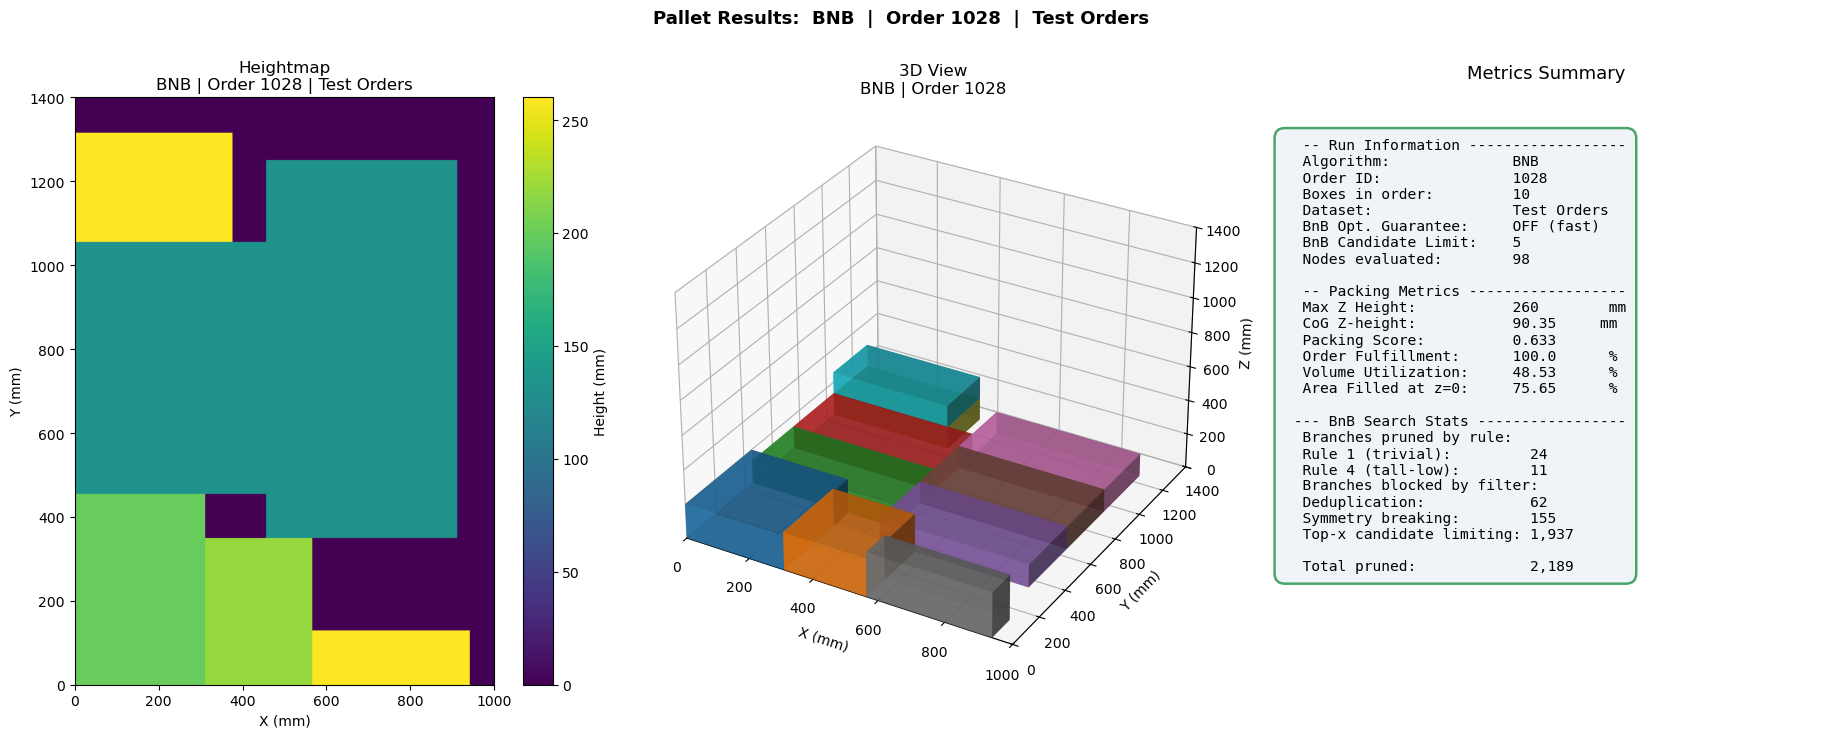

In [ ]:
current_order_dict = test_orders_dict
current_orderID = 15
current_algo = Algorithm.BNB
current_criterion = Criterion.VOLUME
current_metric = Metric.MAX_Z
current_nett = BNB_TOPX_DEFAULT_LIMIT

testing_random_fulfillment = False
testing_optg_comparisons = False
testing_topx_comparisons = False
testing_algo_comparisons = False

given_order_list = list(range(1, 41))
type_2_test_order_list = list(range(1000, 4000))

optg_missing_given_orders = [1, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
optg_missing_test_orders = [2047, 2070, 2122, 2124, 2208, 2223, 2224, 2231, 2248, 2249, 2288, 2305, 2311, 2327, 2347, 2354, 2356, 2377, 2380, 2387, 2393, 2399, 2400, 2403, 2405, 2406, 2416, 2417, 2418, 2421, 2424, 2435, 2445, 2448, 2455, 2462, 2463, 2465, 2476, 2483, 2491, 2497, 2505, 2507, 2511, 2514, 2515, 2520, 2521, 2523, 2525, 2526, 2528, 2529, 2533, 2534, 2539, 2541, 2542, 2545, 2548, 2549, 2552, 2554, 2558, 2561, 2562, 2563, 2570, 2581, 2584, 2591, 2592, 2593, 2596, 2600, 2601, 2602, 2603, 2604, 2609, 2613, 2618, 2619, 2620, 2621, 2622, 2627, 2628, 2636, 2637, 2640, 2641, 2642, 2646, 2647, 2648, 2651, 2653, 2654, 2655, 2657, 2658, 2659, 2661, 2662, 2663, 2664, 2665, 2666, 2667, 2668, 2669, 2670, 2671, 2672, 2673, 2674, 2675, 2676, 2677, 2678, 2679, 2680, 2681, 2682, 2683, 2684, 2685, 2686, 2687, 2688, 2689, 2690, 2691, 2692, 2693, 2694, 2695, 2696, 2697, 2698, 2699, 2700, 2701, 2702, 2703, 2704, 2705, 2706, 2707, 2708, 2709, 2710, 2711, 2712, 2713, 2714, 2715, 2716, 2717, 2718, 2719, 2720, 2721, 2722, 2723, 2724, 2725, 2726, 2727, 2728, 2729, 2730, 2731, 2732, 2733, 2734, 2735, 2736, 2737, 2738, 2739, 2740, 2741, 2742, 2743, 2744, 2745, 2746, 2747, 2748, 2749, 2750, 2751, 2752, 2753, 2754, 2755, 2756, 2757, 2758, 2759, 2760, 2761, 2762, 2763, 2764, 2765, 2766, 2767, 2768, 2769, 2770, 2771, 2772, 2773, 2774, 2775, 2776, 2777, 2778, 2779, 2780, 2781, 2782, 2783, 2784, 2785, 2786, 2787, 2788, 2789, 2790, 2791, 2792, 2793, 2794, 2795, 2796, 2797, 2798, 2799, 2800, 2801, 2802, 2803, 2804, 2805, 2806, 2807, 2808, 2809, 2810, 2811, 2812, 2813, 2814, 2815, 2816, 2817, 2818, 2819, 2820, 2821, 2822, 2823, 2824, 2825, 2826, 2827, 2828, 2829, 2830, 2831, 2832, 2833, 2834, 2835, 2836, 2837, 2838, 2839, 2840, 2841, 2842, 2843, 2844, 2845, 2846, 2847, 2848, 2849, 2850, 2851, 2852, 2853, 2854, 2855, 2856, 2857, 2858, 2859, 2860, 2861, 2862, 2863, 2864, 2865, 2866, 2867, 2868, 2869, 2870, 2871, 2872, 2873, 2874, 2875, 2876, 2877, 2878, 2879, 2880, 2881, 2882, 2883, 2884, 2885, 2886, 2887, 2888, 2889, 2890, 2891, 2892, 2893, 2894, 2895, 2896, 2897, 2898, 2899, 2900, 2901, 2902, 2903, 2904, 2905, 2906, 2907, 2908, 2909, 2910, 2911, 2912, 2913, 2914, 2915, 2916, 2917, 2918, 2919, 2920, 2921, 2922, 2923, 2924, 2925, 2926, 2927, 2928, 2929, 2930, 2931, 2932, 2933, 2934, 2935, 2936, 2937, 2938, 2939, 2940, 2941, 2942, 2943, 2944, 2945, 2946, 2947, 2948, 2949, 2950, 2951, 2952, 2953, 2954, 2955, 2956, 2957, 2958, 2959, 2960, 2961, 2962, 2963, 2964, 2965, 2966, 2967, 2968, 2969, 2970, 2971, 2972, 2973, 2974, 2975, 2976, 2977, 2978, 2979, 2980, 2981, 2982, 2983, 2984, 2985, 2986, 2987, 2988, 2989, 2990, 2991, 2992, 2993, 2994, 2995, 2996, 2997, 2998, 2999]
topx_missing_given_orders = []
topx_missing_test_orders = [2122, 2143, 2189, 2207, 2224, 2249, 2256, 2283, 2288, 2297, 2305, 2311, 2327, 2347, 2354, 2356, 2386, 2399, 2400, 2402, 2403, 2405, 2416, 2417, 2418, 2421, 2435, 2436, 2445, 2448, 2455, 2461, 2462, 2465, 2491, 2497, 2505, 2507, 2520, 2533, 2535, 2539, 2541, 2549, 2552, 2554, 2558, 2561, 2562, 2570, 2582, 2584, 2593, 2596, 2609, 2611, 2612, 2618, 2622, 2636, 2637, 2640, 2641, 2642, 2646, 2647, 2651, 2657, 2659, 2661, 2662, 2669, 2675, 2683, 2685, 2687, 2688, 2690, 2693, 2697, 2698, 2707, 2708, 2709, 2712, 2717, 2718, 2719, 2723, 2726, 2728, 2729, 2731, 2734, 2736, 2737, 2738, 2739, 2741, 2743, 2744, 2746, 2752, 2754, 2755, 2762, 2768, 2771, 2772, 2773, 2782, 2785, 2788, 2789, 2790, 2791, 2795, 2798, 2799, 2800, 2801, 2803, 2804, 2806, 2809, 2811, 2812, 2816, 2819, 2820, 2821, 2826, 2827, 2829, 2831, 2832, 2833, 2834, 2835, 2836, 2839, 2842, 2843, 2844, 2845, 2853, 2857, 2858, 2860, 2862, 2863, 2864, 2866, 2869, 2871, 2874, 2875, 2880, 2881, 2886, 2888, 2889, 2893, 2896, 2898, 2899, 2900, 2901, 2903, 2904, 2906, 2907, 2908, 2909, 2911, 2912, 2914, 2915, 2917, 2919, 2920, 2921, 2922, 2923, 2926, 2927, 2934, 2935, 2938, 2939, 2940, 2946, 2947, 2949, 2952, 2953, 2954, 2955, 2957, 2958, 2959, 2960, 2962, 2963, 2965, 2966, 2970, 2971, 2972, 2973, 2974, 2975, 2980, 2981, 2986, 2989, 2991, 2993, 2996, 2997, 2999]
algo_missing_given_orders = []
algo_missing_test_orders = [3871, 3922, 3959]

if __name__ == "__main__":
    if NOTEBOOK_MODE:
        if current_algo == Algorithm.BNB:
            testpallet, bnb_stats = process_order(current_orderID, algo=current_algo, criterion=current_criterion, order_dict=current_order_dict, metric=current_metric, num_extpts_to_try=current_nett)
            testpallet.get_pallet_results(current_algo, current_orderID, current_order_dict, print_mode=True, bnb_stats=bnb_stats)
        else:
            testpallet, nodes = process_order(current_orderID, algo=current_algo, criterion=current_criterion, order_dict=current_order_dict, metric=current_metric)
            testpallet.get_pallet_results(current_algo, current_orderID, current_order_dict, print_mode=True, nodes=nodes)

    elif testing_random_fulfillment:
        run_random_fulfillment_test(1000, 3999, test_orders_dict, 500, 10000, 100, True)

    elif testing_optg_comparisons:
        with concurrent.futures.ProcessPoolExecutor(max_workers=125) as executor:
            if current_order_dict == orders_dict:
                for i in optg_missing_test_orders:
                    executor.submit(
                        run_optimality_guarantee_test, 
                        start_order=i, 
                        end_order=i, 
                        )
            else:
                for i in optg_missing_given_orders:
                    executor.submit(
                        run_optimality_guarantee_test, 
                        start_order=i, 
                        end_order=i, 
                        )

    elif testing_topx_comparisons:
        with concurrent.futures.ProcessPoolExecutor(max_workers=125) as executor:
            if current_order_dict == orders_dict:
                for i in topx_missing_given_orders:
                    executor.submit(
                        run_topx_limiting_test, 
                        start_order=i, 
                        end_order=i, 
                        order_dict=orders_dict, 
                        print_pallets=False, 
                        save_pallets=True,
                        topx_min = 1,
                        topx_max= 5,
                        topx_step= 1,
                        topx_test_without= False
                        )
            else:
                for i in topx_missing_test_orders:
                    executor.submit(
                        run_topx_limiting_test, 
                        start_order=i, 
                        end_order=i, 
                        order_dict=test_orders_dict, 
                        print_pallets=False, 
                        save_pallets=False,
                        topx_min = 1,
                        topx_max= 15,
                        topx_step= 1,
                        topx_test_without= True
                        )
                    
    elif testing_algo_comparisons:
        with concurrent.futures.ProcessPoolExecutor(max_workers=125) as executor:
            if current_order_dict == orders_dict:
                for i in algo_missing_given_orders:
                    executor.submit(
                        run_algorithm_comparison_test, 
                        start_order=i,
                        end_order=i,
                        order_dict=current_order_dict, 
                        print_pallets=False, 
                        save_pallets=True,
                        )
            else:
                for i in algo_missing_test_orders:
                    executor.submit(
                        run_algorithm_comparison_test, 
                        start_order=i,
                        end_order=i,
                        order_dict=current_order_dict, 
                        print_pallets=False, 
                        save_pallets=False,
                        )
    
    else:
        print("No workload specified. Exiting...")